In [ ]:
# Calibration checker
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

1243536940


In [165]:
offsets = []
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\TimeCalibrationTPPT\time_offset_calibration.tsv'
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\tsvtest1.tsv'
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\tsvtest2.tsv'
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\tsvtest1a.tsv'
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\tsvtest2a.tsv'
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\tsvtest2b.tsv'
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\tsvtest3.tsv'
#offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\tsvtest3a.tsv'
offsetsdir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\tsvtest4.tsv'
with open(offsetsdir, 'r') as f:
    for row in f:
        offsets.append(float(row.split()[4]))
offsets = np.asarray(offsets)

In [166]:
data_dir = r'C:\Users\burri\Documents\PET\TimeCalibration\CalibrationDataPreparer\compressed_photopeak_cut.bin'
num_rows = os.path.getsize(data_dir) // 6
data = np.memmap(data_dir, dtype = np.int16, mode = 'r', shape=(num_rows, 3))
print(num_rows)

195194524


In [167]:
def mimiccalibrate(chunk):
    temp = np.zeros(len(chunk), dtype = np.float32)
    curr = 0
    for row in chunk:
        temp[curr] = row[2] + offsets[row[1]] - offsets[row[0] + 3072]
        curr += 1
    return temp

def mimiccalibrate2(chunk):
    chunk[:, 2] = chunk[:, 2] + offsets[chunk[:, 1]] - offsets[chunk[:, 0] + 3072]
    return chunk

i = 0
chunk = np.copy(data[i * 10000000: (i+1) * 10000000])
#chunk = chunk[chunk[:, 0] < 128]
#chunk = chunk[chunk[:, 1] < 128]
#chunk = chunk[chunk[:, 0] == 0]
print(len(chunk))

10000000


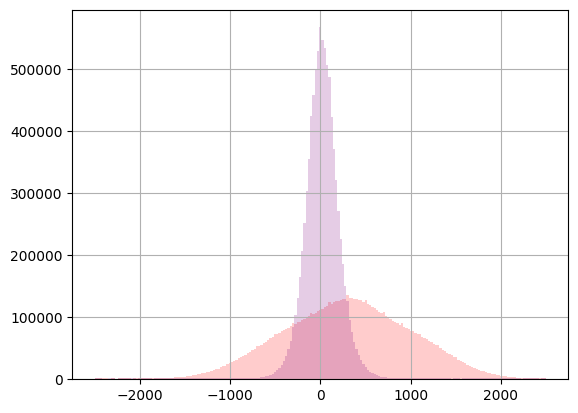

In [168]:
bins = np.linspace(-2500, 2500, 200)
bincenters = [(bins[n] + bins[n + 1]) / 2 for n in range(len(bins) - 1)]

plt.hist(chunk[:,2], bins = bins, color = 'red', alpha = 0.2)
calibrated = mimiccalibrate2(chunk)
plt.hist(calibrated[:,2], bins = bins, color = 'purple', alpha = 0.2)


plt.grid()
plt.show()

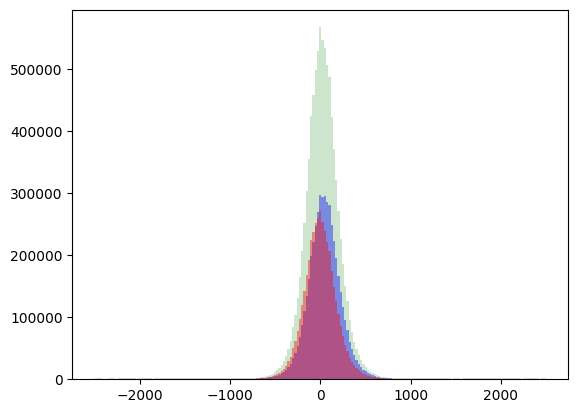

In [170]:
#plt.hist(chunk[:,2], bins = bins, color = 'purple', alpha = 0.2)
plt.hist(calibrated[:,2], bins = bins, color = 'green', alpha = 0.2)

# For splitting into double peak
half1=np.asarray(list(range(0, 34)) + list(range(64, 98)))
def asichalf1(events):
    return events[np.isin(events[:,1] % 128, half1)]
def asichalf2(events):
    return events[~np.isin(events[:,1] % 128, half1)]

hist1 = plt.hist(asichalf1(calibrated)[:,2], bins = bins, color = 'blue', alpha = 0.4)
hist2 = plt.hist(asichalf2(calibrated)[:,2], bins = bins, color = 'red', alpha = 0.4)